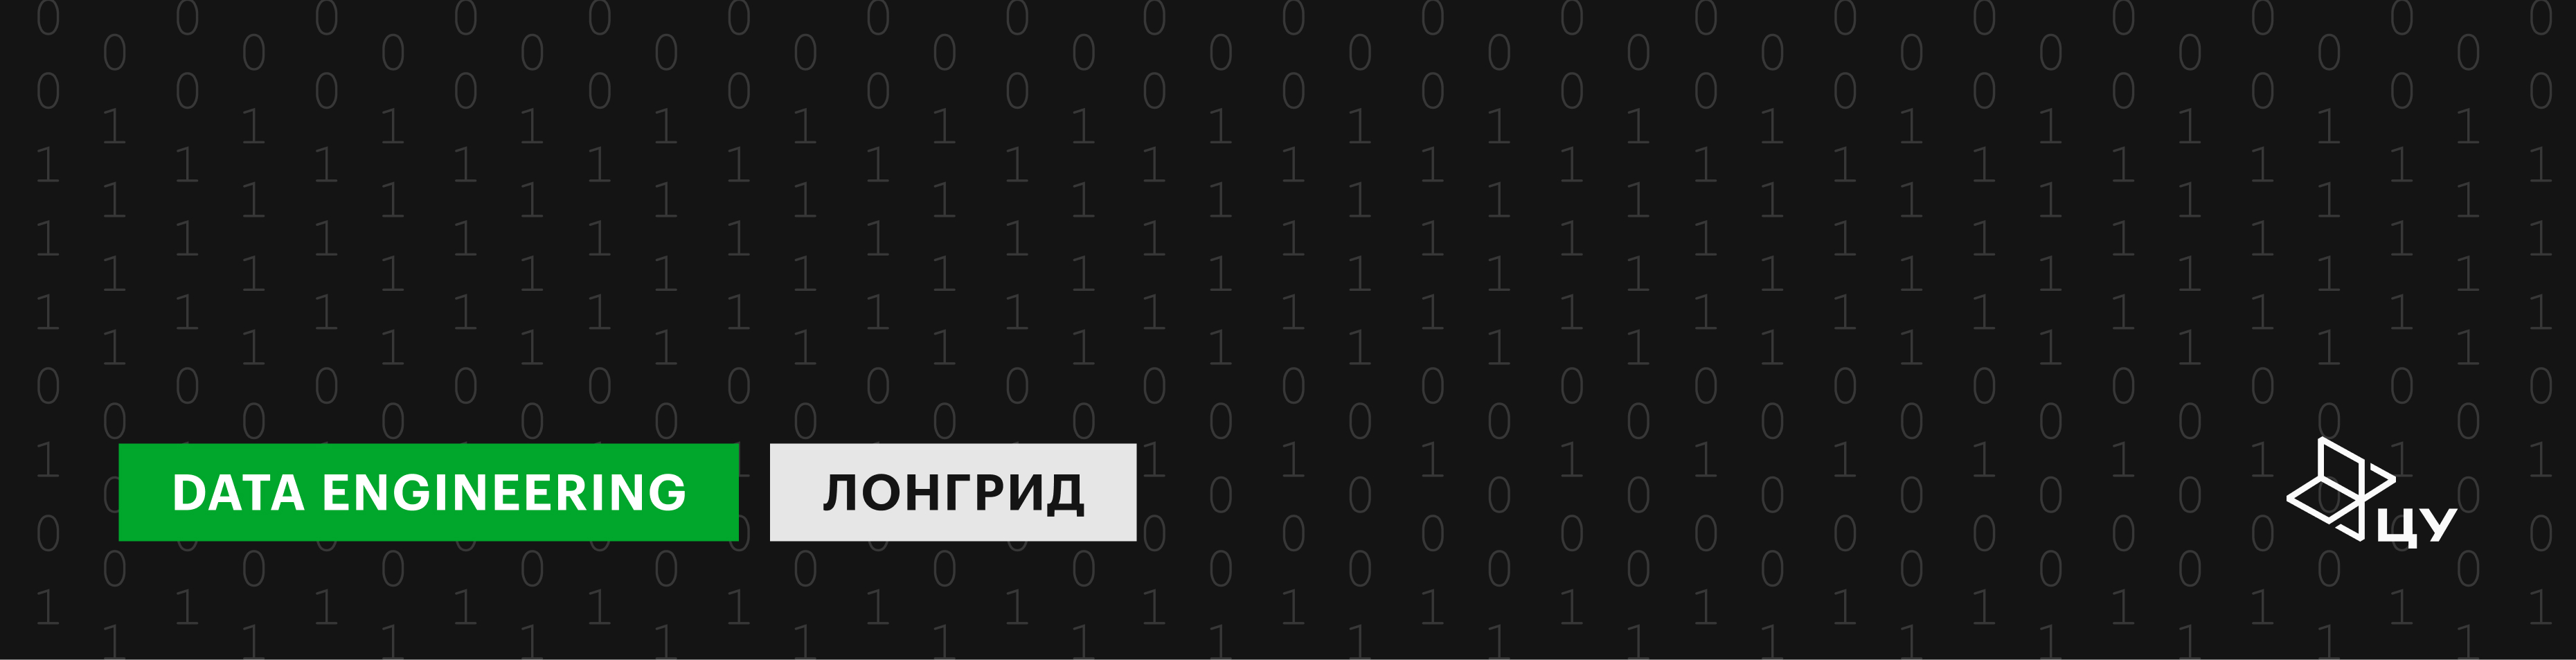

# Лонгрид по теме Введение в инженерию данных. Профессия и основные концепции


В данном материале рассматриваются основные концепции инженерии данных, а также основные инструменты для работы с данными в файловых хранилищах.



Запусти ячейку с кодом, чтобы решать тесты в тексте этого документа.

In [ ]:
import os,requests,time,pandas as pd;u="http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
f="py_workshop.py";
if os.path.exists(f):os.remove(f)
if not os.path.exists(f):
    r=requests.get(u+"get_py_workshop");r.status_code==200 and open(f,"wb").write(r.content) and time.sleep(1)
from py_workshop import *
pd.set_option("display.max_columns", None);pd.set_option("display.width", 2000);pd.set_option("display.max_colwidth", None);pd.set_option("display.max_rows", None)
runner.set_url(u);runner.logon();schema_name = runner.user_schema;config = runner.get_config()
runner.course = 'de'
runner.material( 'de_intro_longread', course_launch='de_2026_fall_cu')

1. Введение: почему появилась инженерия данных
2. Роль Data Engineer и отличия от смежных специалистов
3. Эволюция подходов к хранению данных
- 3.1. Классические хранилища данных (DWH)
- 3.2. Проблемы масштабирования и лаг обработки
- 3.3. Data Lake: первое решение
- 3.4. Data Lakehouse: комбинированная архитектура
4. Файловые форматы: CSV vs Parquet
5. S3 и объектные хранилища: бакеты, ключи, префиксы
6. Обработка данных в объектном хранилище на основе S3
- 6.1. Примеры команд AWS CLI
- 6.2. Boto3: программный доступ из Python
7. DuckDB: SQL-анализ файловых данных
- 7.1. Запросы к CSV, Parquet и объектному хранилищу
8. Заключение

### 1. Введение: почему появилась инженерия данных

Данные являются одним из основных ресурсов современных информационных систем. Организации фиксируют сведения о пользователях, событиях, транзакциях, логах, кликах, операциях и бизнес-процессах. Аналитическая ценность этих сведений возникает только при условии, что данные доступны в согласованном, полном и воспроизводимом виде.

Инженерия данных сформировалась как область, отвечающая за доставку, хранение, преобразование и подготовку данных для последующего анализа, машинного обучения и операционной отчётности.

### 2. Роль инженера данных и отличия от смежных специалистов

**Инженер данных** — специалист, который отвечает за движение данных от источников до потребителей. В зону его ответственности входят форматы файлов, схемы баз данных, пайплайны обработки, расписания выполнения задач, контроль качества данных, обработка сбоев и масштабирование инфраструктуры.

Роль инженера данных удобно рассматривать в сравнении со смежными ролями. Аналитик исследует состояние предметной области и формулирует выводы на основе данных. ML-инженер строит модели машинного обучения и организует их применение. Инженер данных обеспечивает условия, при которых данные доступны этим ролям в корректной и воспроизводимой форме.

В классической модели аналитики обычно работали с заранее подготовленными таблицами в базах данных, ML-инженеры получали подготовленные датасеты, а backend-разработчики обслуживали транзакционные базы приложений. В современных системах эти границы менее жёсткие: аналитические задачи всё чаще выполняются поверх наборов файлов, ML-пайплайны читают данные напрямую из объектных хранилищ, а продуктовые команды ожидают более быстрого доступа к первичным данным. Поэтому базовые компетенции инженерии данных становятся значимыми для широкого круга специалистов.

### 3. Эволюция подходов к хранению данных

#### 3.1. Классические хранилища данных (DWH)

До появления больших объёмов данных аналитика строилась вокруг классических хранилищ, известных как Data Warehouse. В типичном процессе данные из операционных систем регулярно загружались в такое хранилище, где проходили через процессы очистки и трансформации. После этого они агрегировались и становились доступными через SQL, позволяя аналитикам писать запросы к заранее подготовленным таблицам. Классические хранилища данных характеризовались стабильной схемой, небольшим количеством источников, редкими обновлениями (обычно раз в день или реже), строгой типизацией и валидацией данных, а также высокой стоимостью хранения и вычислений.

#### 3.2. Проблемы масштабирования и отставание обработки

Со временем источников стало больше. Появились:
- логи приложений (миллионы строк в день);
- события пользовательского поведения (клики, просмотры);
- внешние выгрузки от партнёров;
- файлы различных форматов;
- полу- и неструктурированные данные (JSON, XML).

Критическая проблема классического подхода — **задержка (лаг) между событием и его доступностью для анализа.**

**Типичный сценарий**

1. 00:00 — событие произошло (пользователь сделал покупку).
2. 01:00 — данные записались в операционную БД.
3. 03:00 — начался ETL-процесс (извлечение данных).
4. 05:00 — ETL завершился, данные в staging-области.
5. 07:00 — трансформации и валидация.
6. 09:00 — загрузка в финальные таблицы DWH.
7. 10:00 — данные доступны аналитику.

**Итог:** задержка между событием и возможностью его анализа составляет 10 часов.

Для многих бизнес-задач такая задержка является существенным ограничением:
- фрод-мониторинг требует реакции в течение минут;
- рекомендательные системы работают в режиме, близком к реальному времени;
- операционные дашборды должны отражать актуальное состояние процессов.

#### 3.3. Data Lake: первое решение

Data Lake стал одним из ответов на ограничения классических хранилищ при росте объёма и разнообразия данных.

**Ключевая идея:** хранить данные в файловом виде и применять схему в момент чтения, а не при записи.

**Преимущества:**
- более низкая стоимость хранения по сравнению с DWH;
- горизонтальное масштабирование;
- поддержка различных форматов: CSV, JSON, Parquet, Avro;
- применение схемы при чтении (schema-on-read);
- простая загрузка новых файлов в хранилище.

**Проблемы Data Lake**

При отсутствии правил организации данных Data Lake может перейти в состояние, которое называют **Data Swamp**. В таком хранилище файлы существуют, но их происхождение, структура, актуальность и качество становятся неочевидными.

| Проблема | Описание | Последствия |
|----------|----------|-------------|
| **Отсутствие схемы** | Структура файла не описана явно | Ошибки при чтении и несовместимость данных |
| **Версионность** | Не определено, какая версия файла является актуальной | Разные пользователи получают разные результаты |
| **Качество** | Отсутствуют проверки дублей и пропусков | Некорректные расчёты |
| **Поиск** | Нет единого каталога данных | Возрастают затраты времени на поиск источников |
| **Права доступа** | Не определены политики чтения и записи | Возникают риски несанкционированного доступа |

#### 3.4. Data Lakehouse: комбинированная архитектура

**Data Lakehouse** — архитектурный подход, который дополняет файловое хранение логическим слоем управления данными.

Основная идея состоит в разделении хранения и вычислений при сохранении табличной модели доступа к данным.

- данные физически размещаются в файлах;
- поверх файлов поддерживается логическая структура: схемы, версии, история изменений, SQL-доступ и транзакционные гарантии.

**Файлы** — физическая форма хранения.  
**Таблицы** — логическое представление данных.

```
┌─────────────────────────────────────┐
│     SQL Query Interface             │
│  (Привычный интерфейс как в DWH)    │
└──────────────┬──────────────────────┘
               │
┌──────────────▼──────────────────────┐
│     Metadata Layer                  │
│  • Схемы таблиц                     │
│  • Версии данных                    │
│  • Индексы и статистика             │
│  • История изменений                │
└──────────────┬──────────────────────┘
               │
┌──────────────▼──────────────────────┐
│     Object Storage (S3)             │
│  • Parquet/ORC-файлы                │
│  • Партиционирование                │
│  • Дешёвое хранение                 │
└─────────────────────────────────────┘

### 4. Файловые форматы: CSV vs Parquet

Формат файла определяет способ физического хранения данных и влияет на объём хранения, скорость чтения и удобство интеграции с вычислительными системами. CSV является текстовым построчным форматом: каждая строка соответствует одной записи, а значения разделены специальным символом-разделителем. Parquet является бинарным колоночным форматом: данные одной колонки хранятся рядом, а схема и типы данных фиксируются внутри файла. Поэтому Parquet обычно эффективнее для аналитических запросов, особенно когда требуется читать ограниченный набор колонок.

Форматы CSV и Parquet используются для разных классов задач.

**CSV (Comma-Separated Values)**

Характеристики:
- текстовый формат;
- построчное хранение: одна строка соответствует одной записи;
- широкая поддержка инструментами обработки данных;
- отсутствие встроенной строгой схемы.

**Parquet (Apache Parquet)**

Характеристики:
- бинарный формат;
- колоночное хранение;
- хранение схемы и типов данных внутри файла;
- эффективное сжатие;
- поддержка predicate pushdown и чтения только необходимых колонок.

**Колоночное и построчное хранение**

**CSV (построчное):**
```
Row 1: FL001, Aeroflot, 2025-12-18, 15000
Row 2: FL002, S7,       2025-12-18, 12000
Row 3: FL003, Pobeda,   2025-12-18, 8000
```

**Parquet (колоночное):**
```
Column flight_id:  [FL001, FL002, FL003]
Column airline:    [Aeroflot, S7, Pobeda]
Column date:       [2025-12-18, 2025-12-18, 2025-12-18]
Column price:      [15000, 12000, 8000]
```

CSV целесообразен, когда источник предоставляет данные только в текстовом виде, требуется ручной просмотр файла или объём данных невелик. Parquet предпочтителен для аналитических нагрузок, долгосрочного хранения и обработки больших наборов данных в системах Spark, DuckDB, ClickHouse и других колоночных движках.

Практический пример: конвертация CSV → Parquet

В следующем примере файл `flights.csv.gz` загружается из репозитория датасетов JupyterHub с помощью команды `runner.ds_load_file("simple_file_pack_01.flights.0")`. Затем DuckDB конвертирует его в формат Parquet.

In [ ]:
import duckdb

flights_path = runner.ds_load_file("simple_file_pack_01.flights.0")

print(f"Файл скачан: {flights_path}")

duckdb.sql(f"""
    COPY (
        SELECT * FROM read_csv_auto('{flights_path}')
    ) TO 'flights.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

In [ ]:
# Проверяем размер
import os
csv_size = os.path.getsize(flights_path) / 1024 / 1024
parquet_size = os.path.getsize('flights.parquet') / 1024 / 1024

print(f"CSV.GZ: {csv_size:.2f} MB")
print(f"Parquet: {parquet_size:.2f} MB")
print(f"Compression ratio: {csv_size / parquet_size:.1f}x")

### 5. S3 и объектные хранилища: бакеты, ключи, префиксы

Amazon S3 (Simple Storage Service) — распространённая модель объектного хранения данных, применяемая как в облачных платформах, так и в S3-совместимых хранилищах.

**S3 не является файловой системой в строгом смысле.**

В традиционной файловой системе используются диски, директории и файлы. В S3 базовыми сущностями являются:
- **бакеты** (buckets) — контейнеры верхнего уровня;
- **объекты** (objects) — сохраняемые файлы или бинарные данные;
- **ключи** (keys) — строковые идентификаторы объектов внутри бакета.

### Анатомия S3 URI
```
s3://my-company-data/raw/flights/2024/12/18/data.csv
│   │                │                          │
│   └─ bucket        └─ key ──────────────────┘
└─ protocol
```

Компоненты URI:
- `s3://` — схема обращения;
- `my-company-data` — имя бакета;
- `raw/flights/2024/12/18/data.csv` — ключ объекта.

Символ `/` внутри ключа не создаёт директории на уровне модели S3. Он используется как часть строки ключа и позволяет интерфейсам отображать объекты в виде иерархии папок.

**Префикс** — начальная часть ключа, используемая для группировки объектов и выборки подмножества файлов.

**Партиционирование** — организация ключей таким образом, чтобы данные можно было эффективно читать по значениям измерений, например по дате.

**Hive-style партиционирование:**
```
s3://data/flights/year=2024/month=12/day=18/data.parquet
                  │          │            │
                  └ключи партиционирования┘
```

Для подключения к S3 используются два параметра доступа:

**Access Key ID** — идентификатор учётной записи или сервисного пользователя.

**Secret Access Key** — секретный ключ доступа. Его нельзя размещать в системах контроля версий, публичных репозиториях или открытых ноутбуках.

В учебной среде параметры подключения хранятся в `config.yaml`, который может быть заполнен автоматически средствами JupyterHub.

In [ ]:
# настройка профиля common — для чтения общего бакета
!aws configure set aws_access_key_id "{config['s3_public']['login']}" --profile common
!aws configure set aws_secret_access_key "{config['s3_public']['password']}" --profile common
!aws configure set region "ru-central1" --profile common

# настройка профиля my - для записи в личную область
!aws configure set aws_access_key_id "{config['s3_my']['login']}" --profile my
!aws configure set aws_secret_access_key "{config['s3_my']['password']}" --profile my
!aws configure set region "ru-central1" --profile my

### 6. Обработка данных в объектном хранилище на основе S3

#### 6.1. Примеры команд AWS CLI

В этом разделе команды AWS CLI приведены как справочные листинги. Они оформлены как markdown-блоки, поскольку в учебном материале важно показать синтаксис команд без их автоматического выполнения.

Практические сценарии работы с S3 будут рассмотрены на семинаре.

Создание бакета:

```python
!aws s3 mb s3://my-new-bucket \
  --endpoint=https://storage.yandexcloud.net \
  --profile common
```

В учебной среде у пользователя может не быть прав на создание бакетов; пример приведён для демонстрации синтаксиса команды.

Просмотр списка бакетов:

```python
!aws s3 ls \
  --endpoint=https://storage.yandexcloud.net \
  --profile common
```

Копирование файла из локальной директории в S3 и обратно выполняется командой `s3 cp`.

```python
!aws s3 cp ./employee.csv s3://culab-student-files/users/{schema_name}/de_intro/employee.csv \
  --endpoint=https://storage.yandexcloud.net \
  --profile my

!aws s3 cp s3://culab-student-files/users/{schema_name}/de_intro/employee.csv ./employee_from_s3.csv \
  --endpoint=https://storage.yandexcloud.net \
  --profile my
```

Удаление пустого бакета:

```python
!aws s3 rb s3://my-new-bucket \
  --endpoint=https://storage.yandexcloud.net \
  --profile common
```

Команда применима только к пустому бакету. В учебной среде права на удаление бакетов, как правило, не предоставляются.

#### 6.2. Boto3: программный доступ из Python

Boto3 — библиотека Python для программного взаимодействия с S3 и S3-совместимыми объектными хранилищами.

В примерах ниже клиент создаётся с учётными данными личного профиля, так как операции записи выполняются в пользовательскую область хранилища.

In [ ]:
import boto3

In [ ]:
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    region_name='ru-central1',
    aws_access_key_id=config['s3_my']['login'],
    aws_secret_access_key=config['s3_my']['password']
)

```python
# Создание бакета показано для демонстрации метода.
# В учебной среде права на эту операцию обычно не предоставляются.
s3_client.create_bucket(
    Bucket='my-new-bucket'
)


# Просмотр списка бакетов показан для демонстрации метода.
# В учебной среде права на эту операцию могут быть ограничены.
response = s3_client.list_buckets()
for bucket in response['Buckets']:
    print(f"{bucket['Name']} - {bucket['CreationDate']}")


# Удаление бакета возможно только для пустого бакета
# и при наличии соответствующих прав доступа.
s3_client.delete_bucket(Bucket='my-new-bucket')
```

Файл `employee.csv` доступен в нашем репозитории датасетов из JupyterHub. Перед загрузкой в S3 его можно получить командой `runner.ds_load_file("simple_file_pack_01.employee.0")`.

In [ ]:
employee_path = runner.ds_load_file("simple_file_pack_01.employee.0")


print(f"Файл скачан: {employee_path}")

# Загрузка файла в S3
# Способ 1: upload_file (для локальных файлов)
s3_client.upload_file(
    Filename=employee_path,
    Bucket='culab-student-files',
    Key=f'users/{schema_name}/de_intro/employee.csv'
)

In [ ]:
# Способ 2: put_object (для данных в памяти)
data = "employee_id,name,surname\n1,William,Bach\n"
s3_client.put_object(
    Bucket='culab-student-files',
    Key=f'users/{schema_name}/de_intro/employee_1row.csv',
    Body=data.encode('utf-8')
)

In [ ]:
# Скачивание файла из S3
# Способ 1: download_file
s3_client.download_file(
    Bucket='culab-student-files',
    Key=f'users/{schema_name}/de_intro/employee.csv',
    Filename='employee_local_data.csv'
)

In [ ]:
# Способ 2: get_object (чтение объекта в память)
response = s3_client.get_object(
    Bucket='culab-student-files',
    Key=f'users/{schema_name}/de_intro/employee.csv'
)
data = response['Body'].read()
print(data.decode('utf-8'))

### 7. DuckDB: SQL-анализ файловых данных

**DuckDB** — встраиваемая аналитическая СУБД, которая позволяет выполнять SQL-запросы непосредственно к файлам. Она не требует отдельного сервера, поддерживает CSV, Parquet и другие форматы, умеет читать наборы файлов по шаблону пути и возвращает результат как обычную таблицу или `pandas.DataFrame`.

#### 7.1. Запросы к CSV, Parquet и объектному хранилищу

In [ ]:
import duckdb

con = duckdb.connect()

In [ ]:
# Прочитать CSV файл
result = con.execute(f"""
    SELECT * FROM read_csv_auto('{flights_path}')
    LIMIT 5
""").fetchall()

for row in result:
    print(row)

In [ ]:
# DuckDB автоматически распознаёт сжатие
result = con.execute(f"""
    SELECT
        airline,
        COUNT(*) as flights_count,
        AVG(ticket_price_usd) as avg_price,
        MIN(ticket_price_usd) as min_price,
        MAX(ticket_price_usd) as max_price
    FROM read_csv_auto('{flights_path}', null_padding=true)
    GROUP BY airline
    ORDER BY flights_count DESC
""").df()  # .df(), .fetchdf() возвращает pandas DataFrame

print(result)

Созданный выше файл `flights.parquet` доступен через тот же SQL-интерфейс. Для аналитических запросов Parquet часто эффективнее CSV, поскольку DuckDB может читать только необходимые колонки.

In [ ]:
result = con.execute("""
    SELECT
        airline,
        COUNT(*) as flights_count,
        AVG(ticket_price_usd) as avg_price
    FROM read_parquet('flights.parquet')
    GROUP BY airline
    ORDER BY flights_count DESC
""").df()

print(result)

DuckDB также может читать данные напрямую из S3 без предварительного копирования файла в локальную директорию. Для этого используется расширение `httpfs` и параметры подключения к S3-совместимому хранилищу.

In [ ]:
student_flights_key = 'users/{schema_name}/de_intro/flights.csv.gz'

s3_client.upload_file(
    Filename=flights_path,
    Bucket='culab-student-files',
    Key=student_flights_key
)

s3_flights_path = f's3://culab-student-files/{student_flights_key}'

con.execute(f"""
    INSTALL httpfs;
    LOAD httpfs;
    SET s3_endpoint='storage.yandexcloud.net';
    SET s3_url_style='path';
    SET s3_region='ru-central1';
    SET s3_access_key_id='{config['s3_my']['login']}';
    SET s3_secret_access_key='{config['s3_my']['password']}';
""")

result = con.execute(f"""
    SELECT COUNT(*) AS rows_count
    FROM read_csv_auto('{s3_flights_path}')
""").df()

print(result)

### 8. Заключение

Классические хранилища данных (Data Warehouse) сохраняют значение для структурированной аналитики, однако их использование становится менее достаточным при росте объёма, скорости поступления и разнообразия данных. Архитектура Data Lakehouse дополняет файловое хранение табличным слоем управления и обеспечивает SQL-доступ к данным в объектном хранилище.

В такой архитектуре важную роль играют форматы файлов. CSV остаётся универсальным форматом обмена, но для аналитической обработки больших наборов данных чаще применяется Parquet: он хранит данные по колонкам, включает схему и позволяет уменьшать объём чтения при выполнении запросов.

Объектные хранилища, совместимые с S3, используют модель бакетов, объектов, ключей и префиксов. Папки в пользовательских интерфейсах являются визуальным представлением префиксов, тогда как физически объект идентифицируется ключом.

Для работы с S3 применяются AWS CLI и библиотеки Python, например boto3. DuckDB дополняет этот стек возможностью выполнять SQL-запросы к локальным файлам и к объектам в S3 без предварительной загрузки данных в реляционную СУБД.

### Вопросы по теме

### Задача 1. Data Lakehouse
Что такое Data Lakehouse?
Выбери один правильный вариант ответа.
```text
1. Новое название для Data Lake
2. Подход, объединяющий дешёвое файловое хранение с SQL-доступом и структурой
3. Замена классического DWH с использованием только реляционных БД
4. Облачное хранилище только для неструктурированных данных
```


In [ ]:
# Введи ответ в задании 1
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(1, solution)


### Задача 2. Parquet и AVG по колонке
Какое ключевое преимущество колоночного формата Parquet
при выполнении запроса SELECT AVG(price) FROM flights?
Выбери один правильный вариант ответа.
```text
1. Parquet автоматически кеширует результаты
2. Parquet читает только колонку price, а не все данные
3. Parquet сжимает данные лучше, чем CSV
4. Parquet поддерживает параллельное чтение
```


In [ ]:
# Введи ответ в задании 2
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(2, solution)


### Задача 3. S3 сущности
Что НЕ является реальной сущностью в Amazon S3?
Выбери один правильный вариант ответа.
```text
1. Бакеты (buckets)
2. Объекты (objects)
3. Папки (folders)
4. Ключи (keys)
```


In [ ]:
# Введи ответ в задании 3
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(3, solution)


### Задача 4. S3 URI
В S3 URI s3://my-company-data/raw/flights/2024/12/18/data.csv
что является ключом объекта?
Выбери один правильный вариант ответа.
```text
1. my-company-data
2. raw/flights/2024/12/18/data.csv
3. data.csv
4. s3://my-company-data
```


In [ ]:
# Введи ответ в задании 4
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(4, solution)


### Задача 5. DuckDB hive_partitioning
Что делает параметр hive_partitioning = true
при чтении партиционированных данных в DuckDB?
Выбери один правильный вариант ответа.
```text
1. Ускоряет чтение файлов в 2 раза
2. Автоматически создаёт колонки из имён партиций (year, month, day)
3. Сортирует данные по партициям
4. Сжимает результат запроса
```


In [ ]:
# Введи ответ в задании 5
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(5, solution)
